# Sequential Dynamics produced by RNNs - Demo

Here, we generate time series data with a sequence-producing RNN which is defined as:

$$\dot{h} = W\phi(h) + Bx(t),$$

where $x(t)$ is a gaussian pulse that starts the sequence. $W$ is defined as a similarity transform of Schur Form $T, $


$$W = Q \times T \times Q^T.$$

We define a Schur Form T as a quasi-lower triangular matrix with $1 \times 1$ and $2 \times 2$ blocks along its diagonal. For simplicity, we set $W$ to be a similarity transform of a lower triangular matrix, where $Q=I$ and $T$. Furthermore, T has distinct negative entries on the diagonal, distinct positive values on the subdiagonal and 0 everywhere else, representing strict feedforward connectivity, i.e. each mode receives inputs only from the directly preceding mode.
<p align="center">
<img class="center" src="../figures/teacher_network.png" height="300"> </p>

In [1]:
from pathlib import Path
import sys
import seaborn as sns
import torch as torch
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT))
from src.data.generation import GaussianPulseDataset

plt.rcParams["figure.figsize"] = (6,3)
plt.style.use('ggplot')
plt.rcParams['axes.facecolor']='w'

In [4]:
# generating dataset
n_neurons = 25
seq_length = 50
n_samples = 500

gps = GaussianPulseDataset(seq_length=seq_length, n_pulse=n_neurons, n_samples = n_samples, sequence_type='rnn', activation_function='tanh')

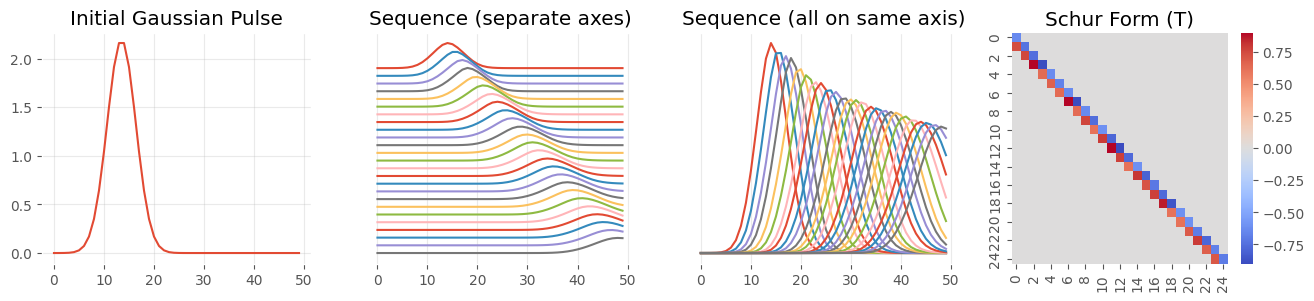

In [5]:
sample = gps[3]

fig, axs = plt.subplots(1,4, figsize=(16,3))
axs[0].plot(sample[0])
axs[0].set_title('Initial Gaussian Pulse')

for n in range(gps.n_pulse):
    axs[1].plot(sample[1][:,n]-n)
axs[1].set_title('Sequence (separate axes)')
axs[1].yaxis.set_ticks([])

axs[2].plot(sample[1])
axs[2].set_title('Sequence (all on same axis)')
axs[2].yaxis.set_ticks([]);

sns.heatmap(gps.sequence.T, cmap="coolwarm", ax=axs[3])
axs[3].set_title('Schur Form (T)');

for a in axs:
    if a != axs[-1]:
        a.grid(True, which="major", color="#BBB", linestyle="-", alpha=0.3)